In [4]:
!cd ~/c/iu9-sql-compiler/ && python -m research.fuzz.cost_stats \
    --cli build-release/bin/sql \
    --data-dir test/static/executor/test_data \
    --count 400 --repeats 5 \
    --out research/cost-stats.csv

collected=25 attempted=25 skipped=0
collected=50 attempted=50 skipped=0
collected=75 attempted=75 skipped=0
collected=99 attempted=100 skipped=0
collected=100 attempted=100 skipped=0
collected=125 attempted=125 skipped=0
collected=150 attempted=150 skipped=0
collected=175 attempted=175 skipped=0
collected=199 attempted=200 skipped=0
collected=200 attempted=200 skipped=0
collected=225 attempted=225 skipped=0
collected=250 attempted=250 skipped=0
collected=275 attempted=275 skipped=0
collected=299 attempted=300 skipped=0
collected=300 attempted=300 skipped=0
collected=325 attempted=325 skipped=0
collected=350 attempted=350 skipped=0
collected=375 attempted=375 skipped=0
collected=399 attempted=400 skipped=0
collected=400 attempted=400 skipped=0
done: collected=400 attempted=400 skipped=0 -> research/cost-stats.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('cost-stats.csv')
df['exec_ms'] = df['exec_us'] / 1e3
print(f'{len(df)} samples')
df[['seed', 'plan_cost', 'exec_us', 'rows']].describe()

400 samples


,seed,plan_cost,exec_us,rows
count,400.000000,4.000000e+02,4.000000e+02,4.000000e+02
mean,199.500000,8.429012e+06,4.220586e+07,1.402288e+04
std,115.614301,7.494437e+07,2.657503e+08,1.405880e+05
min,0.000000,3.660000e+02,3.660000e+02,1.110000e+02
25%,99.750000,2.425500e+03,2.930000e+03,1.927500e+02
50%,199.500000,3.615500e+04,5.414800e+04,3.265000e+02
75%,299.250000,6.801598e+05,1.550466e+06,1.315500e+03
max,399.000000,1.196362e+09,2.984422e+09,2.615226e+06


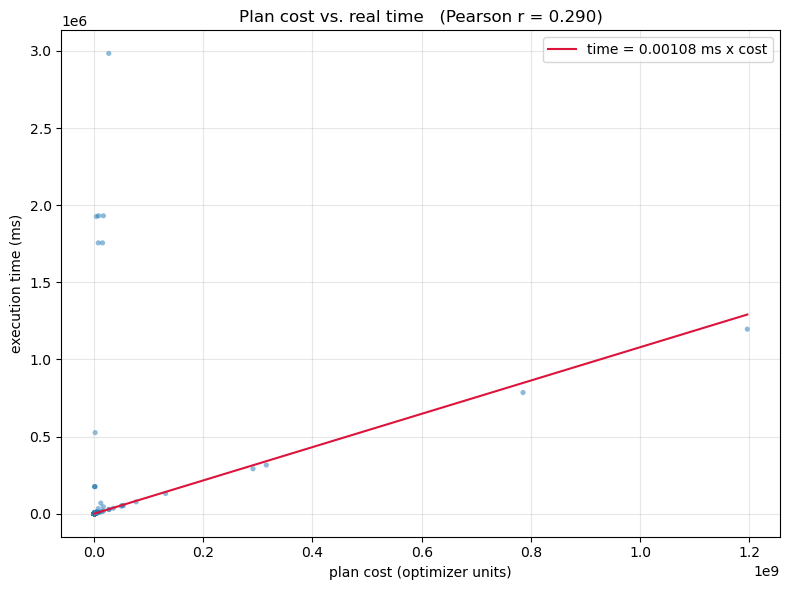

In [6]:
cost = df['plan_cost'].to_numpy(dtype=float)
time_ms = df['exec_ms'].to_numpy(dtype=float)

# Proportional fit through the origin: time = slope * cost.
slope = float(np.sum(cost * time_ms) / np.sum(cost * cost))
r = float(np.corrcoef(cost, time_ms)[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost, time_ms, s=14, alpha=0.5, edgecolor='none')
xs = np.array([0.0, cost.max()])
ax.plot(xs, slope * xs, color='crimson', lw=1.5,
        label=f'time = {slope:.3g} ms x cost')
ax.set_xlabel('plan cost (optimizer units)')
ax.set_ylabel('execution time (ms)')
ax.set_title(f'Plan cost vs. real time   (Pearson r = {r:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

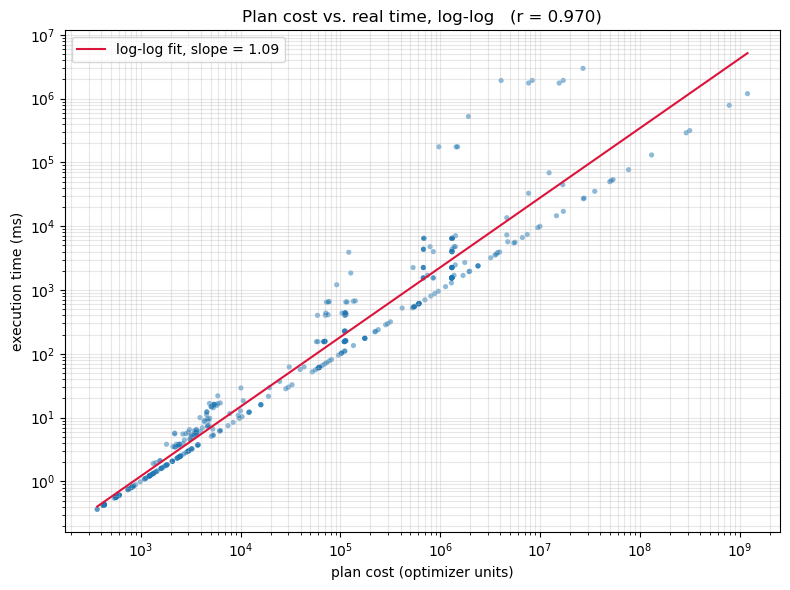

In [7]:
mask = (cost > 0) & (time_ms > 0)
lc = np.log10(cost[mask])
lt = np.log10(time_ms[mask])

a, b = np.polyfit(lc, lt, 1)
r_log = float(np.corrcoef(lc, lt)[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost[mask], time_ms[mask], s=14, alpha=0.5, edgecolor='none')
xs = np.array([cost[mask].min(), cost[mask].max()])
ax.plot(xs, 10**b * xs**a, color='crimson', lw=1.5,
        label=f'log-log fit, slope = {a:.2f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('plan cost (optimizer units)')
ax.set_ylabel('execution time (ms)')
ax.set_title(f'Plan cost vs. real time, log-log   (r = {r_log:.3f})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print(f'samples              : {len(df)}')
print(f'cost range           : {int(cost.min())} .. {int(cost.max())}')
print(f'time range (ms)      : {time_ms.min():.3f} .. {time_ms.max():.1f}')
print(f'Pearson r (linear)   : {r:.3f}')
print(f'log-log slope        : {a:.3f}   (1.0 == perfectly proportional)')
print(f'log-log correlation  : {r_log:.3f}')

samples              : 400
cost range           : 366 .. 1196362017
time range (ms)      : 0.366 .. 2984422.2
Pearson r (linear)   : 0.290
log-log slope        : 1.091   (1.0 == perfectly proportional)
log-log correlation  : 0.970
